In [64]:
import pandas as pd
import numpy as np 

# Talent Pool Estimation for Basketball

This notebook estimates the effective "talent pool" for professional basketball over time by combining:
1. **NBA player birthplace data** — where players come from by U.S. Census region
2. **U.S. Census population data** — regional population proportions over time
3. **UN world population data** — male population aged 20–29 (eligible playing age)
4. **Interest adjustment** — Gallup survey data on basketball interest, lagged by 10 years to reflect when interest during youth translates to professional careers

### State Level Dataset of NBA Players Extracted From Basketball Reference

In [65]:
df = pd.read_csv("/Users/ethanmathew/Desktop/FHMforBasketball/basketball_reference_scraper/data/nba_state_data.csv")

In [66]:
df["birthplace"].unique()
df["birthplace"] = (
    df["birthplace"]
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
)


### Mapping Players to Census Regions and Computing Proportions Over Time

Each player is mapped to one of four U.S. Census regions (Northeast, Midwest, South, West) or "International" based on their birth state. Players are then expanded into per-season rows (one row for each season they were active), so we can track how the regional composition of the NBA has shifted year by year.

This next section obtains the regions of NBA players birthplaces from the years 1947 - 2025 to track the proportion of players from each region. This will serve as a baseline to measure and model the talent pool calculation. 

In [71]:
import pandas as pd
import numpy as np


df["season_min"] = pd.to_numeric(df["season_min"], errors="coerce")
df["season_max"] = pd.to_numeric(df["season_max"], errors="coerce")

# --------------------------------------------------
# 2. DEFINE REGION MAPPING
# --------------------------------------------------

CENSUS_REGIONS = {
    # Northeast
    "Connecticut": "Northeast", "Maine": "Northeast",
    "Massachusetts": "Northeast", "New Hampshire": "Northeast",
    "Rhode Island": "Northeast", "Vermont": "Northeast",
    "New Jersey": "Northeast", "New York": "Northeast",
    "Pennsylvania": "Northeast",

    # Midwest
    "Illinois": "Midwest", "Indiana": "Midwest",
    "Michigan": "Midwest", "Ohio": "Midwest",
    "Wisconsin": "Midwest", "Iowa": "Midwest",
    "Kansas": "Midwest", "Minnesota": "Midwest",
    "Missouri": "Midwest", "Nebraska": "Midwest",
    "North Dakota": "Midwest", "South Dakota": "Midwest",

    # South
    "Delaware": "South", "Florida": "South",
    "Georgia": "South", "Maryland": "South",
    "North Carolina": "South", "South Carolina": "South",
    "Virginia": "South", "West Virginia": "South",
    "Alabama": "South", "Kentucky": "South",
    "Mississippi": "South", "Tennessee": "South",
    "Arkansas": "South", "Louisiana": "South",
    "Oklahoma": "South", "Texas": "South",

    # West
    "Arizona": "West", "Colorado": "West",
    "Idaho": "West", "Montana": "West",
    "Nevada": "West", "New Mexico": "West",
    "Utah": "West", "Wyoming": "West",
    "Alaska": "West", "California": "West",
    "Hawaii": "West", "Oregon": "West",
    "Washington": "West"
}


def extract_census_region(birthplace):
    if pd.isna(birthplace):
        return "Unknown"
    # parts = [x.strip() for x in birthplace.split(",")]

    if birthplace in CENSUS_REGIONS:
        # state = parts[-2] if len(parts) >= 2 else None
        return CENSUS_REGIONS.get(birthplace, "Unknown")
    else:
        return "International"

df["birthplace"] = (
    df["birthplace"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
)
df["region"] = df["birthplace"].apply(
    lambda x: extract_census_region(
        str(x).replace("\xa0", " ").strip()
    )
)


rows = []

for _, row in df.iterrows():
    if pd.isna(row["season_min"]) or pd.isna(row["season_max"]):
        continue

    for year in range(int(row["season_min"]), int(row["season_max"]) + 1):
        rows.append({
            "season": year,
            "region": row["region"]
        })

expanded_df = pd.DataFrame(rows)


season_counts = (
    expanded_df
    .groupby(["season", "region"])
    .size()
    .reset_index(name="count")
)

season_counts["total_players"] = (
    season_counts
    .groupby("season")["count"]
    .transform("sum")
)

season_counts["proportion"] = (
    season_counts["count"] / season_counts["total_players"]
)

season_region_proportions = season_counts.sort_values(
    ["season", "proportion"],
    ascending=[True, False]
)

print(season_region_proportions.head(20))

    season         region  count  total_players  proportion
2     1947      Northeast     75            161    0.465839
1     1947        Midwest     44            161    0.273292
3     1947          South     19            161    0.118012
4     1947           West     16            161    0.099379
0     1947  International      7            161    0.043478
7     1948      Northeast     52            114    0.456140
6     1948        Midwest     31            114    0.271930
9     1948           West     18            114    0.157895
8     1948          South     11            114    0.096491
5     1948  International      2            114    0.017544
12    1949      Northeast     63            177    0.355932
11    1949        Midwest     61            177    0.344633
13    1949          South     27            177    0.152542
14    1949           West     25            177    0.141243
10    1949  International      1            177    0.005650
16    1950        Midwest     97        

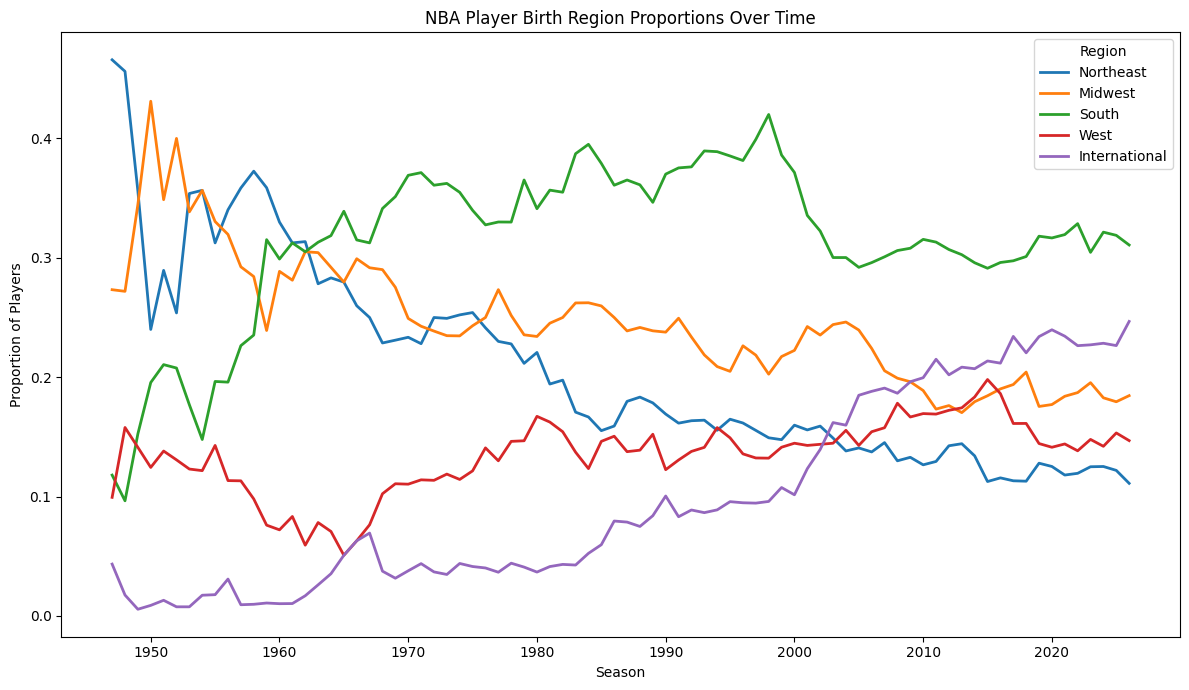

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=season_region_proportions,
    x="season",
    y="proportion",
    hue="region",
    linewidth=2
)

plt.title("NBA Player Birth Region Proportions Over Time")
plt.xlabel("Season")
plt.ylabel("Proportion of Players")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

### Visualizing NBA Player Birthplace Proportions by Region

This plot shows how the share of NBA players from each Census region has changed from 1947 to present. The Northeast and Midwest dominated early basketball, but their share has steadily declined as the South, West, and international players have grown.

We look specifically at Northeast and Midwest region during throughout this time which during the 50s and 60s, primarily dominated the game of basketball. 

In [72]:
import pandas as pd
proportions = pd.read_csv("apportionment.csv")

### Loading U.S. Census Apportionment Data

The Census apportionment dataset provides resident population by state and region at each decennial census. We filter to region-level rows from 1950 onward and compute each region's share of the total U.S. population. This gives us the baseline population distribution to compare against NBA player origins.

In [73]:
proportions.head()

,Name,Geography Type,Year,Resident Population,Percent Change in Resident Population,Resident Population Density,Resident Population Density Rank,Number of Representatives,Change in Number of Representatives,Average Apportionment Population Per Representative
0,Alabama,State,1910,"2,138,093",16.9,42.2,25.0,10.0,1.0,"213,809"
1,Alaska,State,1910,"64,356",1.2,0.1,52.0,NaN,NaN,NaN
2,Arizona,State,1910,"204,354",66.2,1.8,49.0,NaN,NaN,NaN
3,Arkansas,State,1910,"1,574,449",20.0,30.3,30.0,7.0,0.0,"224,921"
4,California,State,1910,"2,377,549",60.1,15.3,38.0,11.0,3.0,"216,051"


In [74]:
columns = ["Name", "Geography Type", "Year", "Resident Population"]
region_prop = proportions[(proportions["Year"] >= 1950) & (proportions["Geography Type"] == "Region")][columns]
region_prop["Resident Population"] = (
    region_prop["Resident Population"]
        .str.replace(",", "", regex=False)
        .astype(float)
)

In [75]:
year_sums = region_prop.groupby("Year")["Resident Population"].transform('sum')
region_prop["year_sum"] = year_sums
region_prop["proportion"] = region_prop["Resident Population"] / year_sums

In [76]:
region_prop

,Name,Geography Type,Year,Resident Population,year_sum,proportion
280,Midwest Region,Region,1950,44460762.0,151325798.0,0.293808
281,Northeast Region,Region,1950,39477986.0,151325798.0,0.260881
282,South Region,Region,1950,47197088.0,151325798.0,0.311891
283,West Region,Region,1950,20189962.0,151325798.0,0.133420
337,Midwest Region,Region,1960,51619139.0,179323175.0,0.287855
338,Northeast Region,Region,1960,44677819.0,179323175.0,0.249147
339,South Region,Region,1960,54973113.0,179323175.0,0.306559
340,West Region,Region,1960,28053104.0,179323175.0,0.156439
394,Midwest Region,Region,1970,56571663.0,203211926.0,0.278388
395,Northeast Region,Region,1970,49040703.0,203211926.0,0.241328


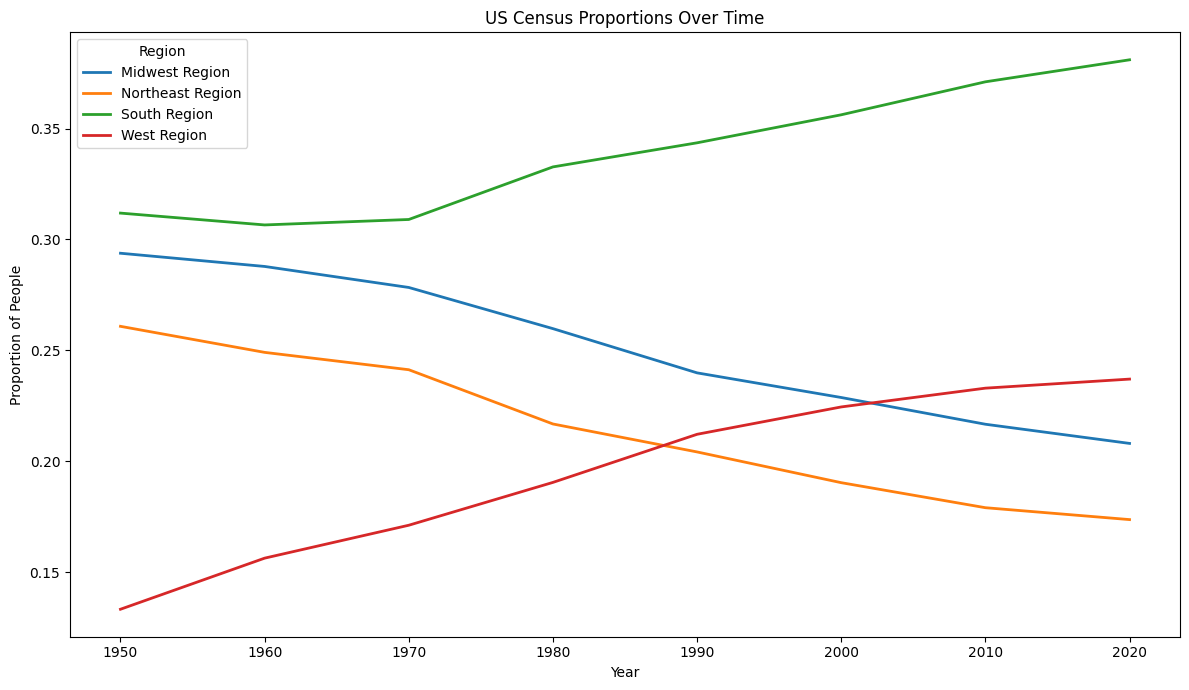

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=region_prop,
    x="Year",
    y="proportion",
    hue="Name",
    linewidth=2
)

plt.title("US Census Proportions Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of People")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

The plot above shows overall population to see how region proportions tack from 1950 to 2020

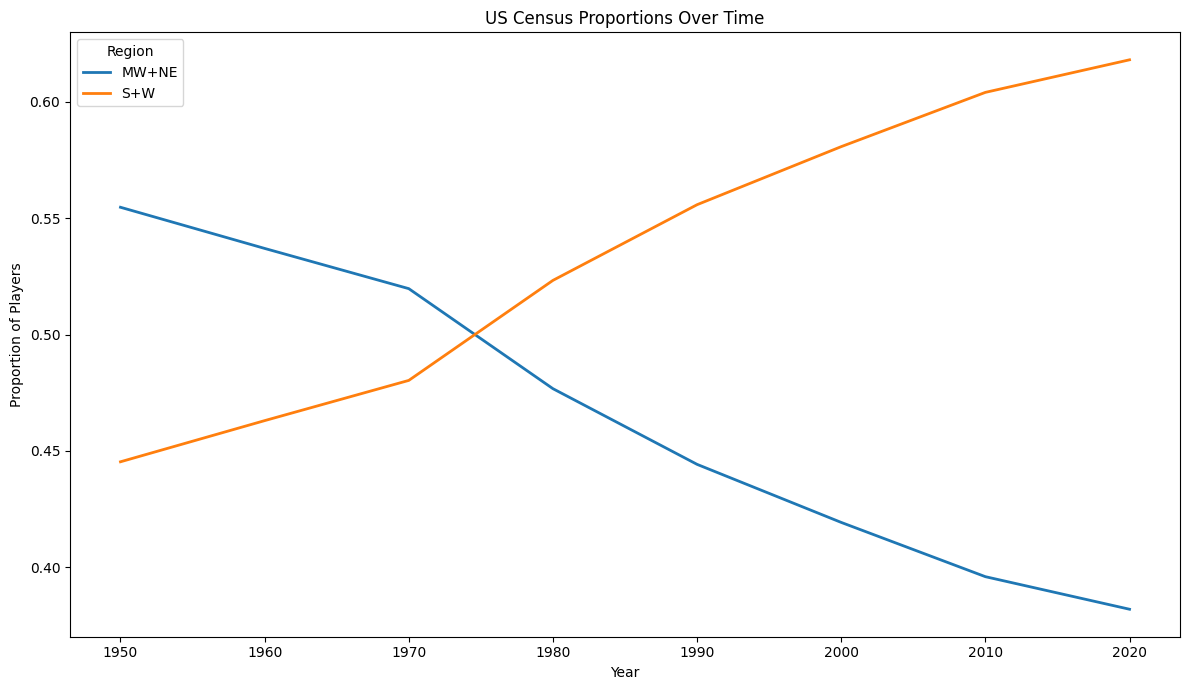

In [13]:
#### PROPORTION OF MW+NE vs. S+W ####
region_prop["Region_Group"] = region_prop["Name"].replace(
    {"Midwest Region": "MW+NE", "Northeast Region": "MW+NE", "South Region": "S+W", "West Region" : "S+W"}
)
grouped_props = (
    region_prop
        .groupby(["Year", "Region_Group"])["Resident Population"]
        .sum()
        .reset_index()
)
total_per_year = grouped_props.groupby("Year")["Resident Population"].transform("sum")
grouped_props["Share"] = grouped_props["Resident Population"] / total_per_year

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=grouped_props,
    x="Year",
    y="Share",
    hue="Region_Group",
    linewidth=2
)

plt.title("US Census Proportions Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of Players")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

### Grouped Comparisons: Northeast+Midwest vs. South+West

To simplify the analysis, regions are grouped into two blocks:
- **MW+NE** (Midwest + Northeast) — the historically basketball-dominant regions
- **S+W** (South + West) — regions that have grown in both population and NBA representation

The following plots compare these grouped shares for both the general population and NBA player origins.

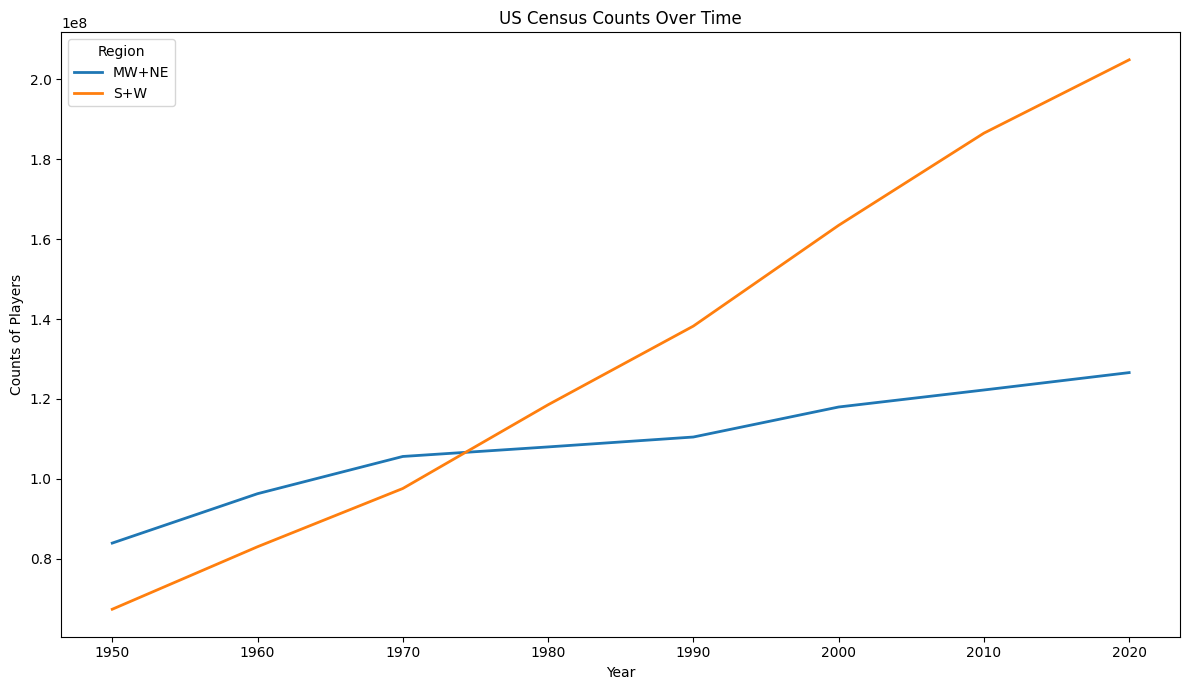

In [14]:
#### RAW COUNTS OF MW+NE vs. S+W ####
region_prop["Region_Group"] = region_prop["Name"].replace(
    {"Midwest Region": "MW+NE", "Northeast Region": "MW+NE", "South Region": "S+W", "West Region" : "S+W"}
)
grouped_counts = (
    region_prop
        .groupby(["Year", "Region_Group"])["Resident Population"]
        .sum()
        .reset_index()
)
total_per_year = grouped_counts.groupby("Year")["Resident Population"].transform("sum")

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=grouped_counts,
    x="Year",
    y="Resident Population",
    hue="Region_Group",
    linewidth=2
)

plt.title("US Census Counts Over Time")
plt.xlabel("Year")
plt.ylabel("Counts of Players")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

In [15]:
season_region_proportions["region_grouped"] = season_region_proportions["region"].replace(
    {"Northeast" : "NE+MW", 
    "Midwest" : "NE+MW", 
    "West" : "S+W+Intl", 
    "South" : "S+W+Intl",
    "International" : "S+W+Intl"}
)

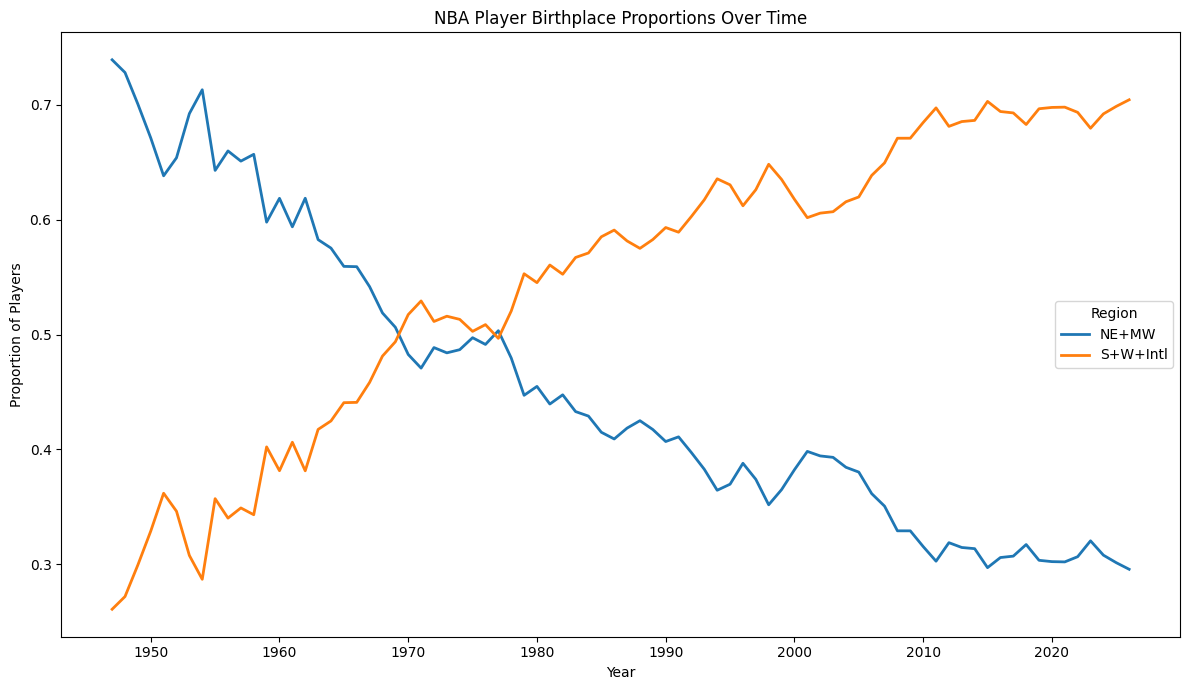

In [16]:
grouped_nba = season_region_proportions.groupby(["season", "region_grouped"])["proportion"].sum().reset_index()

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=grouped_nba,
    x="season",
    y="proportion",
    hue="region_grouped",
    linewidth=2
)

# sns.lineplot(
#     data=grouped_props[grouped_props["Region_Group"] == "MW+NE"],
#     x="Year",
#     y="Share",
#     linewidth=2
# )

plt.title("NBA Player Birthplace Proportions Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of Players")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

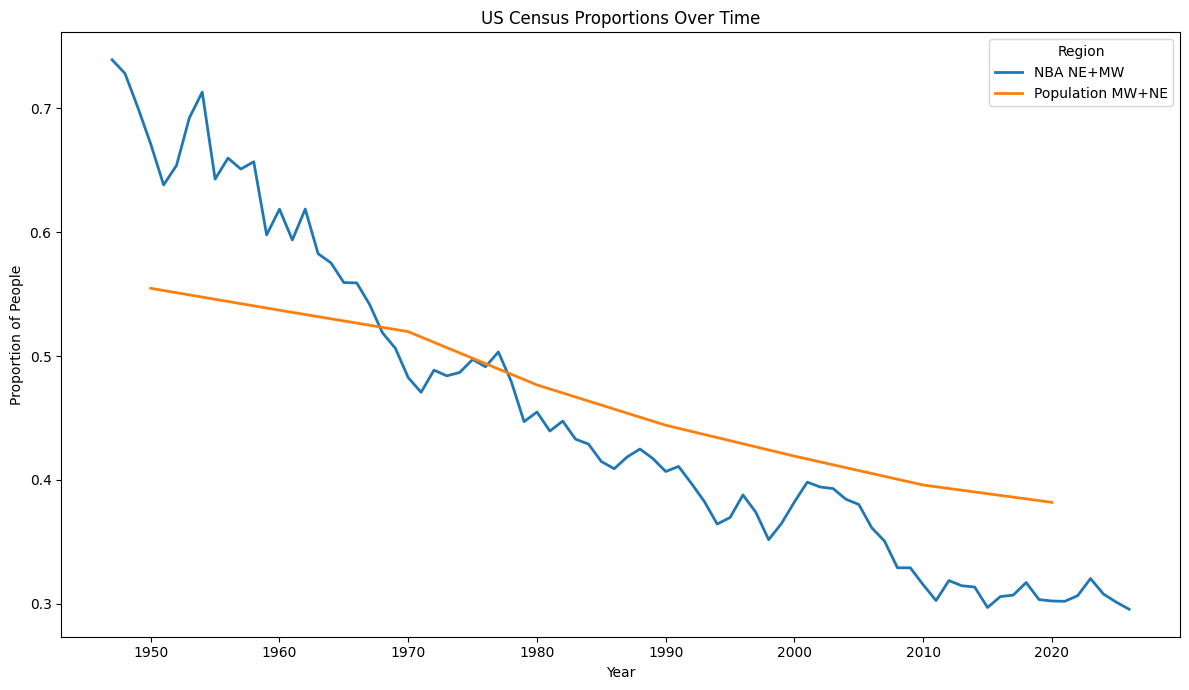

In [78]:
# grouped_nba
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=grouped_nba[grouped_nba["region_grouped"] == "NE+MW"],
    x="season",
    y="proportion",
    linewidth=2,
    label="NBA NE+MW"
)

sns.lineplot(
    data=grouped_props[grouped_props["Region_Group"] == "MW+NE"],
    x="Year",
    y="Share",
    linewidth=2,
    label="Population MW+NE"
)

plt.title("US Census Proportions Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of People")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

### Overlaying NBA and Population Proportions for NE+MW

This plot overlays the NBA player share from the Northeast+Midwest against the general population share of those same regions. The gap between the two lines reveals how overrepresented (or underrepresented) these regions are in the NBA relative to their population.

In [79]:
#https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=CSV%20format
population = pd.read_csv("population.csv")

/var/folders/pk/vjdnd39913sgqxdcnpt9gxc00000gn/T/ipykernel_1956/1605757105.py:2: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  population = pd.read_csv("population.csv")


### UN World Population Data: Male Population Aged 20–29

We load the UN World Population Prospects dataset and filter to U.S. males aged 20–29 — the primary age range for professional basketball players. This gives an absolute measure of the eligible talent base over time, which we'll combine with the regional proportions to estimate the talent pool.

In [80]:
population.head()

,SortOrder,LocID,Notes,ISO3_code,ISO2_code,SDMX_code,LocTypeID,LocTypeName,ParentID,Location,VarID,Variant,Time,MidPeriod,AgeGrp,AgeGrpStart,AgeGrpSpan,PopMale,PopFemale,PopTotal
0,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,1950,0,0,1,1255.174,1217.287,2472.461
1,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,1950,1,1,1,1079.222,1055.572,2134.794
2,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,1950,2,2,1,1017.686,986.275,2003.961
3,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,1950,3,3,1,971.427,928.270,1899.697
4,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,1950,4,4,1,908.551,856.560,1765.111


In [81]:
regions_needed = [
    "United States of America",
]
df_filtered = population[
    (population["Variant"] == "Medium") &         # use medium projection
    (population["AgeGrpStart"].between(20, 29)) & # ages 20–29 inclusive
    (population["Time"] >= 1950) & 
    (population["Location"].isin(regions_needed))
]

# Keep needed columns
df_filtered = df_filtered[["Location", "Time", "AgeGrpStart", "PopMale"]]

# Group and sum ages 20–29
population_data = (
    df_filtered
    .groupby(["Location", "Time"], as_index=False)
    .agg(pop_20_29=("PopMale", "sum"))
)

# Optional: divide by 1000 if needed
population_data["pop_20_29"] /= 1e3

# Rename columns
population_data = population_data.rename(columns={
    "Location": "region",
    "Time": "year"
})

# Optional region recoding
population_data["region"] = population_data["region"].replace({
    "United States of America": "US",
    "Canada": "Can",
    "WORLD": "world"
})

print(population_data.head())

  region  year  pop_20_29
0     US  1950  11.917317
1     US  1951  11.808511
2     US  1952  11.678468
3     US  1953  11.538420
4     US  1954  11.400677


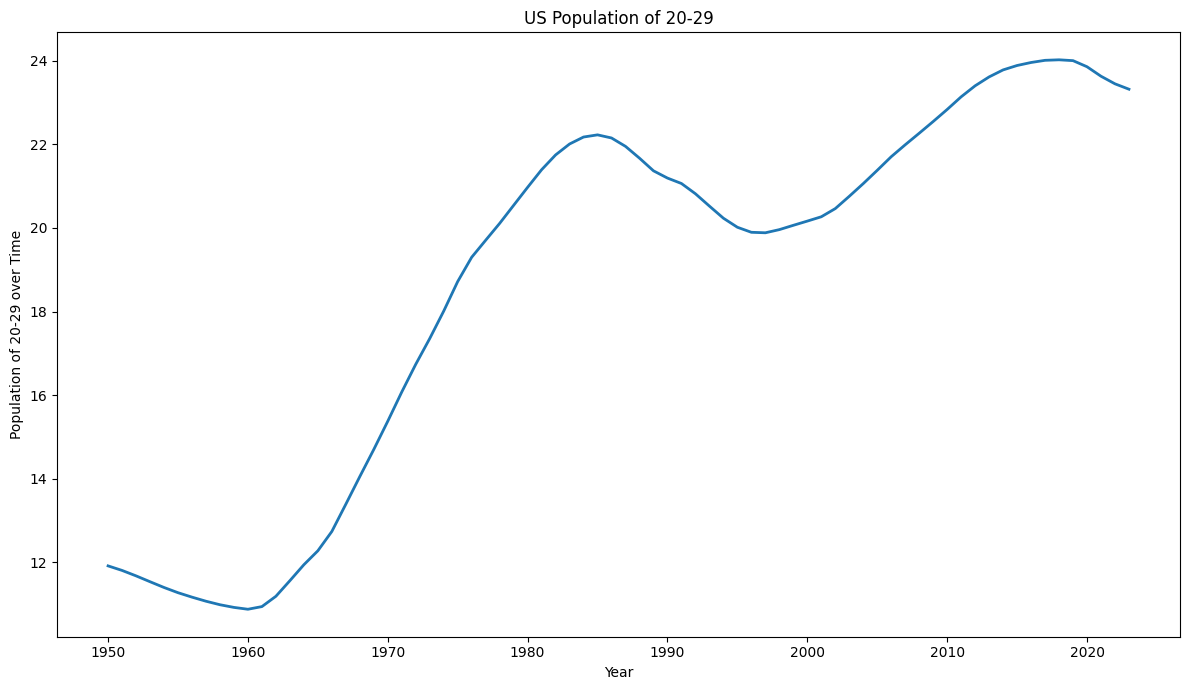

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=population_data,
    x="year",
    y="pop_20_29",
    linewidth=2,
)

# plt.vlines(x = [1944.5, 1966, 1984], linestyles='dashed', ymin=0, ymax = 7)

plt.title("US Population of 20-29")
plt.xlabel("Year")
plt.ylabel("Population of 20-29 Males over Time")
# plt.legend(title="Region")
plt.tight_layout()
plt.show()

In [93]:
# population_data
# grouped_nba
grouped_props[grouped_props["Region_Group"] == "MW+NE"]

props = grouped_props[grouped_props["Region_Group"] == "MW+NE"].set_index("Year")
full_years = pd.RangeIndex(
    start=props.index.min(),
    stop=props.index.max() + 7
)
props = props.reindex(full_years)
props["Share"] = props["Share"].interpolate(method="linear")
props = props.reset_index().rename(columns={"index": "Year"})

### Computing the Talent Pool

The talent pool is estimated using the formula:

$$\text{Talent Pool} = \frac{\text{Population Share (MW+NE)} \times \text{Male Pop 20–29}}{\text{NBA Player Share (NE+MW)}}$$

The Census population share (available only at decennial intervals) is linearly interpolated to get yearly values. The NBA proportion from the NE+MW region acts as a "thermometer" — when these historically dominant regions produce a smaller share of players, it implies the effective talent pool drawing from other regions has grown.

In [100]:
grouped_nba[grouped_nba["region_grouped"] == "NE+MW"]

,season,region_grouped,proportion
0,1947,NE+MW,0.739130
2,1948,NE+MW,0.728070
4,1949,NE+MW,0.700565
6,1950,NE+MW,0.671111
8,1951,NE+MW,0.638158
...,...,...,...
150,2022,NE+MW,0.306604
152,2023,NE+MW,0.320423
154,2024,NE+MW,0.307953
156,2025,NE+MW,0.301394


In [101]:
props

,Year,Region_Group,Resident Population,Share
0,1950,MW+NE,83938748.0,0.554689
1,1951,NaN,NaN,0.552920
2,1952,NaN,NaN,0.551152
3,1953,NaN,NaN,0.549383
4,1954,NaN,NaN,0.547614
...,...,...,...,...
72,2022,NaN,NaN,0.381943
73,2023,NaN,NaN,0.381943
74,2024,NaN,NaN,0.381943
75,2025,NaN,NaN,0.381943


In [102]:
population_data

,region,year,pop_20_29
0,US,1950,11.917317
1,US,1951,11.808511
2,US,1952,11.678468
3,US,1953,11.538420
4,US,1954,11.400677
...,...,...,...
69,US,2019,24.001929
70,US,2020,23.856126
71,US,2021,23.629033
72,US,2022,23.447503


In [103]:
years = []
talent_pool = []
for year in range(1950, 2023):
    prop_nba = grouped_nba[
        (grouped_nba["region_grouped"] == "NE+MW") &
        (grouped_nba["season"] == year)
    ]["proportion"].iloc[0]
    
    prop_pop = props[
        props["Year"] == year
    ]["Share"].iloc[0]
    
    prop_eligible = population_data[
        population_data["year"] == year
    ]["pop_20_29"].iloc[0]
    tp = prop_pop * prop_eligible / prop_nba
    
    years.append(year)
    talent_pool.append(tp)

In [104]:
merged = (
    grouped_nba[grouped_nba["region_grouped"] == "NE+MW"]
    .merge(props, left_on="season", right_on="Year")
    .merge(population_data, left_on="season", right_on="year")
)

merged["talent_pool"] = (
    merged["Share"] *
    merged["pop_20_29"] /
    merged["proportion"]
)

In [105]:
import pandas as pd

talent_df = merged[["season", "talent_pool"]].copy()
talent_df = talent_df.rename(columns={"season": "year"})
talent_df = talent_df.sort_values("year").reset_index(drop=True)

print(talent_df.head())

   year  talent_pool
0  1950     9.849940
1  1951    10.231269
2  1952     9.844222
3  1953     9.156350
4  1954     8.755670


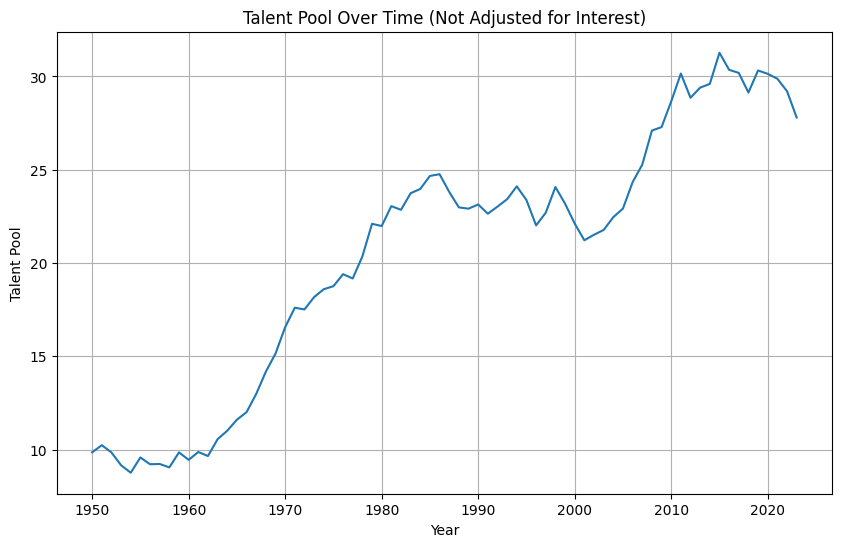

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(talent_df["year"], talent_df["talent_pool"])
plt.title("Talent Pool Over Time (Not Adjusted for Interest)")
plt.xlabel("Year")
plt.ylabel("Talent Pool")
plt.grid(True)
plt.show()

In [107]:
# talent_df.to_csv("talent_pool.csv")

In [108]:
talent_df

,year,talent_pool
0,1950,9.849940
1,1951,10.231269
2,1952,9.844222
3,1953,9.156350
4,1954,8.755670
...,...,...
69,2019,30.318800
70,2020,30.138604
71,2021,29.875645
72,2022,29.209035


In [109]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

interest_raw = pd.read_csv("gallup.csv")
interest_raw["year"] = interest_raw["X.1"].apply(lambda x: int(x[-4:]))
interest_col = [col for col in interest_raw.columns if "interest" in col.lower() or "basketball" in col.lower()][0]

interest_df = interest_raw[["year", interest_col]].copy()
interest_df.columns = ["year", "interest"]
interest_df["interest"] = interest_df["interest"].apply(lambda x: x * 0.01)

years = np.arange(interest_df["year"].min(), interest_df["year"].max() + 1)

interest_full = pd.DataFrame({"year": years})
interest_full = interest_full.merge(interest_df, on="year", how="left")

interest_full["interest"] = interest_full["interest"].interpolate()

X = interest_full["year"].values.reshape(-1, 1)
y = interest_full["interest"].values

spline = SplineTransformer(n_knots=10, degree=3)
X_spline = spline.fit_transform(X)

model = LinearRegression().fit(X_spline, y)
interest_full["interest_smooth"] = model.predict(X_spline)

interest_full["interest_smooth"] = np.maximum(interest_full["interest_smooth"], 0.05)


df = talent_df.merge(interest_full[["year", "interest_smooth"]], on="year", how="left")


df["talent_adj"] = df["talent_pool"] * df["interest_smooth"]


X = df["year"].values.reshape(-1, 1)
y = df["talent_adj"].values

spline2 = SplineTransformer(n_knots=10, degree=3)
X_spline2 = spline2.fit_transform(X)

model2 = LinearRegression().fit(X_spline2, y)
df["talent_adj_smooth"] = model2.predict(X_spline2)

# Create lagged interest (shift forward by 10 years)
interest_full["interest_lag10"] = interest_full["interest_smooth"].shift(10)

# Merge lagged version instead of current interest
df = talent_df.merge(
    interest_full[["year", "interest_lag10"]],
    on="year",
    how="left"
)

# Handle missing early years (first 10 years will be NaN)
df["interest_lag10"] = df["interest_lag10"].bfill()

# Apply adjustment
df["talent_adj"] = df["talent_pool"] * df["interest_lag10"]

### Adjusting for Basketball Interest (Gallup Data)

The raw talent pool doesn't account for how popular basketball is at any given time. We use Gallup survey data on basketball interest, smoothed with a cubic spline, and **lag it by 10 years** — the idea being that interest during someone's youth (around age 10–15) influences whether they pursue basketball seriously enough to reach the professional level a decade later.

The interest-adjusted talent pool is:

$$\text{Talent Pool (Adjusted)} = \text{Talent Pool} \times \text{Interest}_{t-10}$$

In [110]:
df

,year,talent_pool,interest_lag10,talent_adj
0,1950,9.849940,0.084610,0.833403
1,1951,10.231269,0.086761,0.887680
2,1952,9.844222,0.089127,0.877382
3,1953,9.156350,0.091537,0.838149
4,1954,8.755670,0.093887,0.822047
...,...,...,...,...
71,2019,30.318800,0.111465,3.379499
72,2020,30.138604,0.109253,3.292731
73,2021,29.875645,0.107559,3.213401
74,2022,29.209035,0.106491,3.110502


In [63]:
df.to_csv("talent_pool.csv")

### Export

The final interest-adjusted talent pool is saved to `talent_pool.csv` for use in downstream analyses.